In [5]:
import os
print(os.getcwd())

/Users/vihangainduwara/Downloads/archive


In [6]:
train_dir = "train"
test_dir = "test"

In [7]:
import os

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['malignant', 'benign']
Test folders: ['malignant', 'benign']


In [8]:
import os

train_dir = "train"
test_dir = "test"

print("Current working directory:", os.getcwd())
print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Current working directory: /Users/vihangainduwara/Downloads/archive
Train folders: ['malignant', 'benign']
Test folders: ['malignant', 'benign']


In [9]:
for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        print(f"Train - {folder}: {len(os.listdir(folder_path))} images")

for folder in os.listdir(test_dir):
    folder_path = os.path.join(test_dir, folder)
    if os.path.isdir(folder_path):
        print(f"Test - {folder}: {len(os.listdir(folder_path))} images")

Train - malignant: 1197 images
Train - benign: 1441 images
Test - malignant: 300 images
Test - benign: 360 images


In [10]:
for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        print(f"Train - {folder}: {len(os.listdir(folder_path))} images")

for folder in os.listdir(test_dir):
    folder_path = os.path.join(test_dir, folder)
    if os.path.isdir(folder_path):
        print(f"Test - {folder}: {len(os.listdir(folder_path))} images")

Train - malignant: 1197 images
Train - benign: 1441 images
Test - malignant: 300 images
Test - benign: 360 images


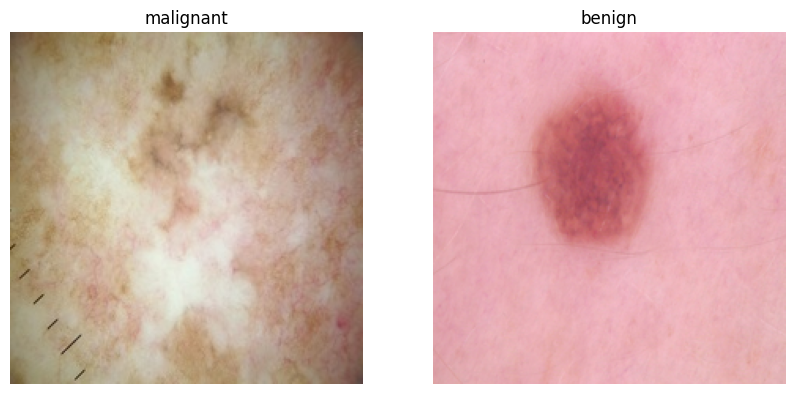

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(10, 5))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    sample_image = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image)
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [12]:
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)
    sample_image = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image)
    img = Image.open(img_path)
    print(f"{cls} image size: {img.size}")

malignant image size: (224, 224)
benign image size: (224, 224)


In [13]:
import sys
print(sys.executable)

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

/opt/anaconda3/envs/melanodetect/bin/python
TensorFlow version: 2.18.1
GPU devices: []


In [14]:
import os
import tensorflow as tf

train_dir = "train"
test_dir = "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_dataset.class_names)

Found 2638 files belonging to 2 classes.
Found 660 files belonging to 2 classes.
Class names: ['benign', 'malignant']


In [15]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [16]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 408ms/step - accuracy: 0.5671 - loss: 0.7681 - val_accuracy: 0.6545 - val_loss: 0.5514
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 439ms/step - accuracy: 0.7616 - loss: 0.4936 - val_accuracy: 0.7803 - val_loss: 0.4443
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 40s 475ms/step - accuracy: 0.7961 - loss: 0.4313 - val_accuracy: 0.8076 - val_loss: 0.4078
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 32s 383ms/step - accuracy: 0.7900 - loss: 0.4242 - val_accuracy: 0.7712 - val_loss: 0.4199
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 31s 369ms/step - accuracy: 0.8059 - loss: 0.4103 - val_accuracy: 0.8197 - val_loss: 0.3598
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 31s 368ms/step - accuracy: 0.8093 - loss: 0.3988 - val_accuracy: 0.8318 - val_loss: 0.3744
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 366ms/step - accuracy: 0.8131 - loss: 0.3755 - val_accuracy: 0.8091 - val_loss: 0.3801
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 364ms/step - accuracy: 0.8124 - loss: 0.3618 - val_accu

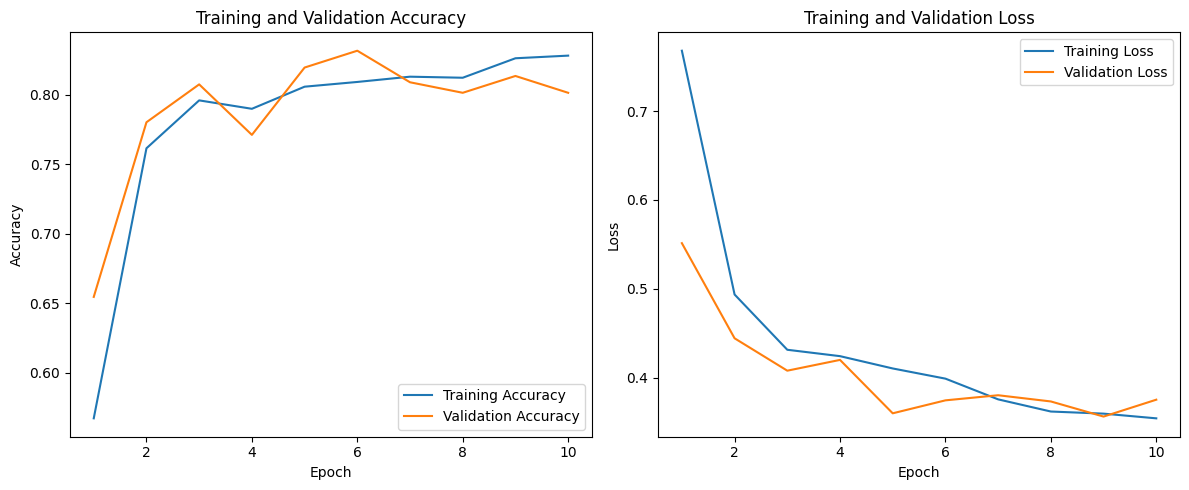

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.8015 - loss: 0.3751
Test Loss: 0.3751343786716461
Test Accuracy: 0.8015151619911194


In [26]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(int)

print("True labels:", len(y_true))
print("Predicted labels:", len(y_pred))

True labels: 660
Predicted labels: 660


2026-03-08 14:35:55.399671: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted Label: benign
Confidence: 0.9973050355911255


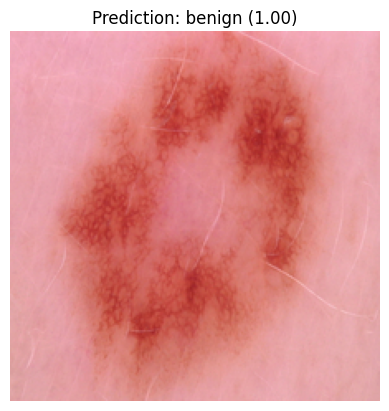

In [27]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img_path = "test/benign/" + os.listdir("test/benign")[0]   # change path if needed

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

label = "malignant" if prediction > 0.5 else "benign"
confidence = prediction if prediction > 0.5 else 1 - prediction

print("Predicted Label:", label)
print("Confidence:", float(confidence))

plt.imshow(load_img(img_path))
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.axis("off")
plt.show()

Predicted Label: benign
Confidence: 0.9973050355911255


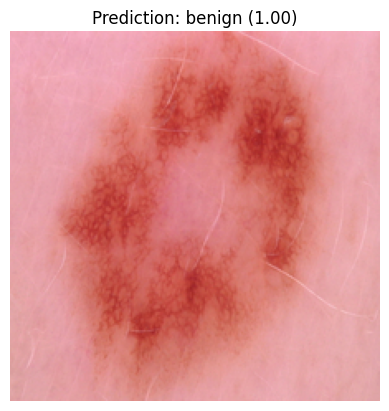

In [28]:
import os
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img_path = "test/benign/" + os.listdir("test/benign")[0]

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

label = "malignant" if prediction > 0.5 else "benign"
confidence = prediction if prediction > 0.5 else 1 - prediction

print("Predicted Label:", label)
print("Confidence:", float(confidence))

plt.imshow(load_img(img_path))
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.axis("off")
plt.show()

In [29]:
import os
print(os.path.exists("skin_cancer_cnn_baseline.keras"))

False


In [30]:
model.save("skin_cancer_cnn_baseline.keras")

In [31]:
import os
print(os.path.exists("skin_cancer_cnn_baseline.keras"))

True


In [32]:
from tensorflow.keras.models import load_model

model = load_model("skin_cancer_cnn_baseline.keras")
print("Model loaded successfully")

Model loaded successfully


Predicted Label: benign
Confidence: 0.9973050355911255


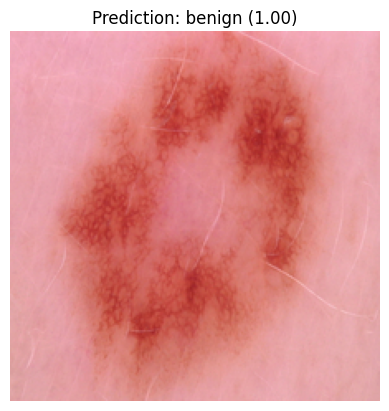

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

img_path = "test/benign/" + os.listdir("test/benign")[0]

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

label = "malignant" if prediction > 0.5 else "benign"
confidence = prediction if prediction > 0.5 else 1 - prediction

print("Predicted Label:", label)
print("Confidence:", float(confidence))

plt.imshow(load_img(img_path))
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.axis("off")
plt.show()

Predicted Label: benign
Confidence: 0.8366909027099609


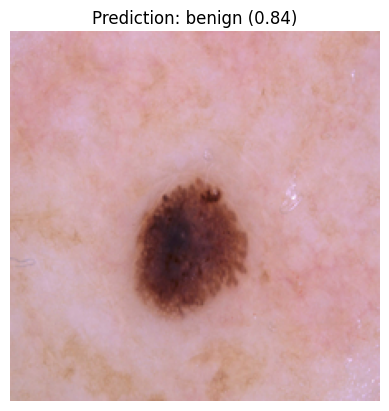

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

img_path = "test/malignant/" + os.listdir("test/malignant")[0]

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

label = "malignant" if prediction > 0.5 else "benign"
confidence = prediction if prediction > 0.5 else 1 - prediction

print("Predicted Label:", label)
print("Confidence:", float(confidence))

plt.imshow(load_img(img_path))
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.axis("off")
plt.show()

In [36]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d Conv2D
max_pooling2d MaxPooling2D
conv2d_1 Conv2D
max_pooling2d_1 MaxPooling2D
conv2d_2 Conv2D
max_pooling2d_2 MaxPooling2D
flatten Flatten
dense Dense
dropout Dropout
dense_1 Dense


In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

def get_img_array(img_path, size=(224, 224)):
    img = load_img(img_path, target_size=size)
    array = img_to_array(img) / 255.0
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [40]:
img_path = "test/malignant/" + os.listdir("test/malignant")[0]

img_array = get_img_array(img_path)

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_2")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

AttributeError: The layer sequential has never been called and thus has no defined output.

In [41]:
import tensorflow as tf
import numpy as np

_ = model(tf.zeros((1, 224, 224, 3)))
print("Model called successfully")

Model called successfully


In [42]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Make sure model has been called
    _ = model(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.outputs[0]]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        return heatmap.numpy()
    heatmap /= max_val

    return heatmap.numpy()

In [43]:
img_path = "test/malignant/" + os.listdir("test/malignant")[0]

img_array = get_img_array(img_path)

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_2")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


ValueError: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.

In [44]:
inputs = tf.keras.Input(shape=(224, 224, 3))
outputs = model(inputs)
cam_model = tf.keras.Model(inputs, outputs)

In [45]:
heatmap = make_gradcam_heatmap(img_array, cam_model, last_conv_layer_name="conv2d_2")

ValueError: No such layer: conv2d_2. Existing layers are: ['input_layer_1', 'sequential'].

In [46]:
base_model = cam_model.get_layer("sequential")
print([layer.name for layer in base_model.layers])

['conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1', 'conv2d_2', 'max_pooling2d_2', 'flatten', 'dense', 'dropout', 'dense_1']


In [47]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, cam_model, last_conv_layer_name):
    base_model = cam_model.get_layer("sequential")

    grad_model = tf.keras.models.Model(
        inputs=cam_model.inputs,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            cam_model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()

In [48]:
img_path = "test/malignant/" + os.listdir("test/malignant")[0]

img_array = get_img_array(img_path)

heatmap = make_gradcam_heatmap(img_array, cam_model, last_conv_layer_name="conv2d_2")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_66']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m5811655568\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.81960785, 0.6666667 , 0.7411765 ],\n         [0.8235294 , 0.6784314 , 0.74509805],\n         [0.83137256, 0.68235296, 0.7647059 ],\n         ...,\n         [0.8235294 , 0.63529414, 0.627451  ],\n         [0.79607844, 0.6117647 , 0.5882353 ],\n         [0.78431374, 0.60784316, 0.5882353 ]],\n\n        [[0.8235294 , 0.67058825, 0.74509805],\n         [0.8117647 , 0.6666667 , 0.73333335],\n         [0.8235294 , 0.6784314 , 0.74509805],\n         ...,\n         [0.8156863 , 0.6392157 , 0.6156863 ],\n         [0.8       , 0.627451  , 0.62352943],\n         [0.7921569 , 0.61960787, 0.62352943]],\n\n        [[0.81960785, 0.6666667 , 0.7411765 ],\n         [0.8235294 , 0.6627451 , 0.73333335],\n         [0.8117647 , 0.6627451 , 0.74509805],\n         ...,\n         [0.8235294 , 0.6431373 , 0.6509804 ],\n         [0.8235294 , 0.65882355

In [49]:
import tensorflow as tf

def build_gradcam_model_from_sequential(base_model, last_conv_layer_name="conv2d_2"):
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = inputs
    last_conv_output = None

    for layer in base_model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[last_conv_output, x])
    return grad_model

grad_model = build_gradcam_model_from_sequential(model, last_conv_layer_name="conv2d_2")
print("Grad-CAM model built successfully")

Grad-CAM model built successfully


In [50]:
import numpy as np

def make_gradcam_heatmap(img_array, grad_model):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

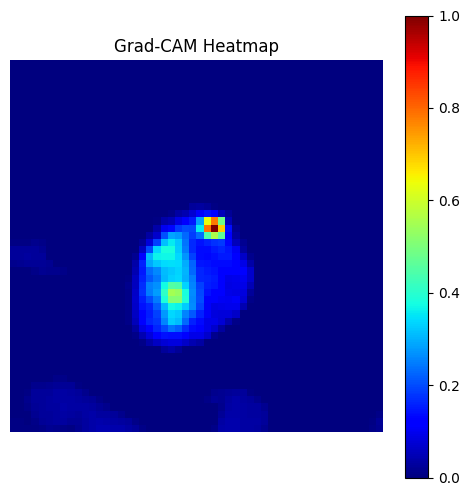

In [51]:
img_path = "test/malignant/" + os.listdir("test/malignant")[0]

img_array = get_img_array(img_path)

heatmap = make_gradcam_heatmap(img_array, grad_model)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.axis("off")
plt.show()

In [52]:
import matplotlib.cm as cm
from tensorflow.keras.utils import load_img, img_to_array, array_to_img

def display_gradcam_overlay(img_path, heatmap, alpha=0.4):
    img = load_img(img_path)
    img = img_to_array(img)

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")
    plt.show()

/var/folders/2j/svk12gt97wgdx51b5jxk3c4r0000gn/T/ipykernel_14672/3276747932.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


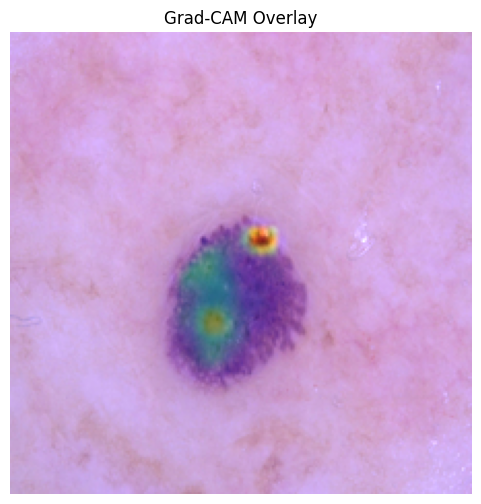

In [53]:
display_gradcam_overlay(img_path, heatmap)

In [54]:
def predict_and_show_gradcam(img_path, model, grad_model):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]
    label = "malignant" if prediction > 0.5 else "benign"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    heatmap = make_gradcam_heatmap(img_array, grad_model)

    print("Predicted Label:", label)
    print("Confidence:", float(confidence))

    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(img_path))
    plt.title(f"Original Image\nPrediction: {label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    display_gradcam_overlay(img_path, heatmap)

Predicted Label: benign
Confidence: 0.8366909027099609


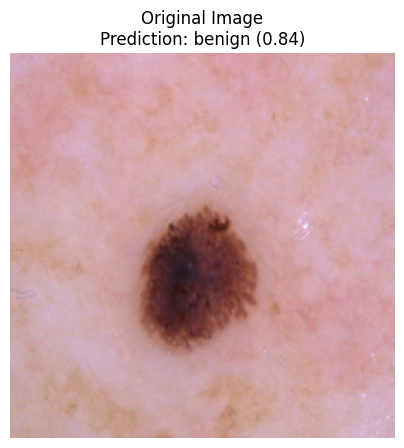

/var/folders/2j/svk12gt97wgdx51b5jxk3c4r0000gn/T/ipykernel_14672/3276747932.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


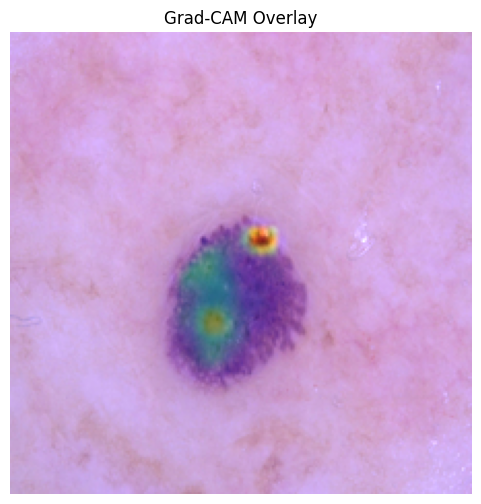

In [55]:
predict_and_show_gradcam(img_path, model, grad_model)

In [1]:
from tensorflow.keras.models import load_model

best_binary_model = load_model(binary_checkpoint_path_v2)
print("Best binary model loaded successfully")

NameError: name 'binary_checkpoint_path_v2' is not defined

In [2]:
import os

binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"
print(os.path.exists(binary_checkpoint_path_v2))

True


In [4]:
from tensorflow.keras.models import load_model

binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"

best_binary_model = load_model(binary_checkpoint_path_v2)
print("Best binary model loaded successfully")

Best binary model loaded successfully


In [5]:
from tensorflow.keras.models import load_model

binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"

best_binary_model = load_model(binary_checkpoint_path_v2)
print("Best binary model loaded successfully")

Best binary model loaded successfully


In [6]:
import numpy as np

binary_test_generator.reset()
binary_pred_probs = best_binary_model.predict(binary_test_generator, verbose=1).flatten()
binary_true_labels = binary_test_generator.classes

print("Total predictions:", len(binary_pred_probs))
print("Total true labels:", len(binary_true_labels))

NameError: name 'binary_test_generator' is not defined

In [7]:
import os
import glob
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)
print(df.shape)

(10015, 7)


In [8]:
 image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))
all_image_paths = image_paths_part1 + image_paths_part2

image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

df["image_path"] = df["image_id"].map(image_path_dict)
print("Missing image paths:", df["image_path"].isna().sum())

Missing image paths: 0


In [9]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

binary_test_df = binary_test_df.reset_index(drop=True)

print(binary_test_df.shape)
print(binary_test_df["binary_label"].value_counts())

(1503, 9)
binary_label
benign       1210
malignant     293
Name: count, dtype: int64


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BINARY_IMG_SIZE = (224, 224)
BINARY_BATCH_SIZE = 16

binary_val_test_datagen = ImageDataGenerator(rescale=1./255)

binary_test_generator = binary_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(binary_test_generator.class_indices)

Found 1503 validated image filenames belonging to 2 classes.
{'benign': 0, 'malignant': 1}


In [12]:
import numpy as np

binary_test_generator.reset()
binary_pred_probs = best_binary_model.predict(binary_test_generator, verbose=1).flatten()
binary_true_labels = binary_test_generator.classes

print("Total predictions:", len(binary_pred_probs))
print("Total true labels:", len(binary_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step
Total predictions: 1503
Total true labels: 1503


In [13]:
import numpy as np

binary_test_generator.reset()
binary_pred_probs = best_binary_model.predict(binary_test_generator, verbose=1).flatten()
binary_true_labels = binary_test_generator.classes

print("Total predictions:", len(binary_pred_probs))
print("Total true labels:", len(binary_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step
Total predictions: 1503
Total true labels: 1503


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
results = []

for t in thresholds:
    preds = (binary_pred_probs > t).astype(int)

    acc = accuracy_score(binary_true_labels, preds)
    precision = precision_score(binary_true_labels, preds)
    recall = recall_score(binary_true_labels, preds)
    f1 = f1_score(binary_true_labels, preds)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "precision_malignant": precision,
        "recall_malignant": recall,
        "f1_malignant": f1
    })

threshold_results_df = pd.DataFrame(results)
threshold_results_df

,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.50,0.814371,0.537634,0.341297,0.417537
1,0.45,0.819029,0.542510,0.457338,0.496296
2,0.40,0.813041,0.519868,0.535836,0.527731
3,0.35,0.803061,0.495868,0.614334,0.548780
4,0.30,0.792415,0.478161,0.709898,0.571429
